# Healthcare Dataset — Logistic Regression (Corrected)

This notebook predicts `Medical Condition` from patient attributes using
Logistic Regression. It fixes the following issues found in the original
version:

1. Inconsistent `Y`/`y` variable naming that only worked because of
   leftover kernel state (would crash on a clean run).
2. A duplicate `pd.read_csv()` call that silently discarded an earlier
   data-cleaning step.
3. Dead code and markdown that didn't match what the notebook actually did.
4. No baseline comparison — accuracy alone is misleading with 6 classes,
   so we now compare the model against a random-guess baseline.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## 1. Load and Clean Data

We load the CSV once and clean it here. Because we only load it once,
this cleaning step will not get silently overwritten later (this was
bug #2 in the original notebook).

In [2]:
df = pd.read_csv("hospital.csv")

# Clean once, use everywhere below
df["Medical Condition"] = df["Medical Condition"].str.lower()

df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [3]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

## 2. Exploratory Plots

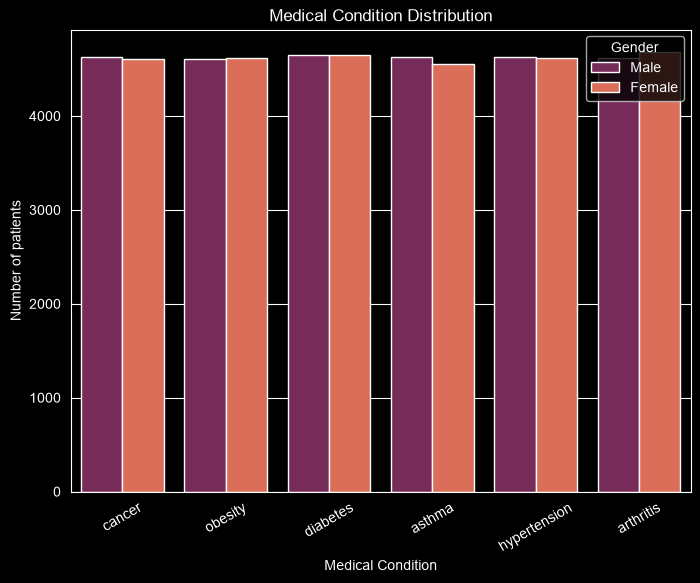

In [4]:
plt.figure(figsize=(8, 6))
sns.countplot(
    data=df,
    x="Medical Condition",
    hue="Gender",
    palette="rocket"
)
plt.title("Medical Condition Distribution")
plt.xlabel("Medical Condition")
plt.ylabel("Number of patients")
plt.xticks(rotation=30)
plt.show()

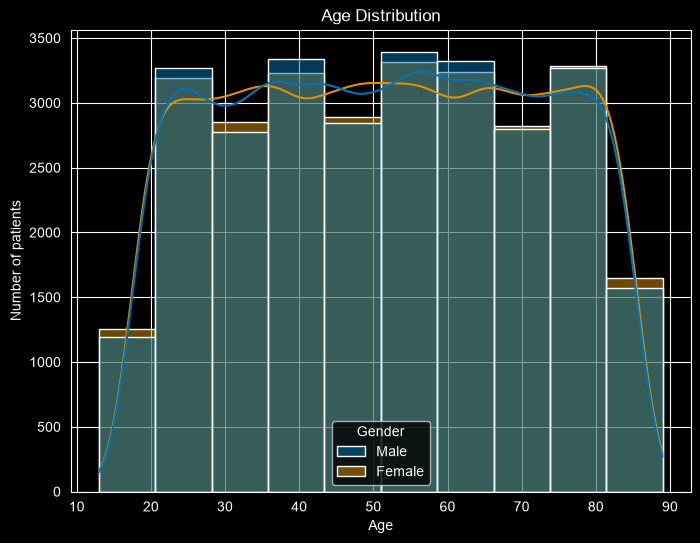

In [5]:
plt.figure(figsize=(8, 6))
sns.histplot(
    data=df,
    x="Age",
    hue="Gender",
    palette="colorblind",
    kde=True,
    bins=10
)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of patients")
plt.show()

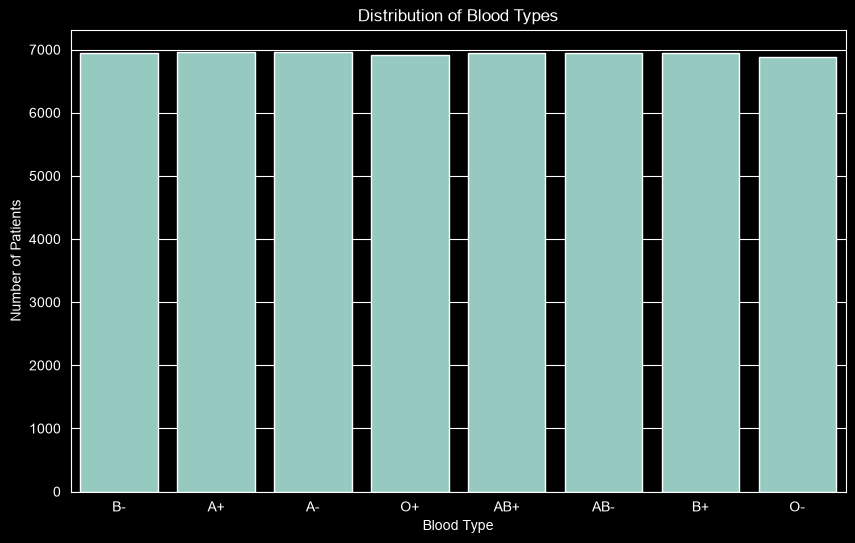

In [6]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Blood Type")
plt.title("Distribution of Blood Types")
plt.xlabel("Blood Type")
plt.ylabel("Number of Patients")
plt.show()

## 3. Select Features and Target

`Name`, `Doctor`, `Hospital`, `Insurance Provider`, `Billing Amount`,
`Room Number`, `Date of Admission`, and `Discharge Date` are dropped —
they're identifiers or unrelated to the medical question, or (in the
case of Billing Amount) a separate potential target of their own.

Target: `Medical Condition`.

In [7]:
X = df.drop(
    columns=[
        "Medical Condition",
        "Name",
        "Doctor",
        "Hospital",
        "Insurance Provider",
        "Billing Amount",
        "Room Number",
        "Date of Admission",
        "Discharge Date"
    ]
)

y = df["Medical Condition"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:", X.columns.tolist())
print("\nTarget classes:", y.unique())

X shape: (55500, 6)
y shape: (55500,)

Features: ['Age', 'Gender', 'Blood Type', 'Admission Type', 'Medication', 'Test Results']

Target classes: <ArrowStringArray>
['cancer', 'obesity', 'diabetes', 'asthma', 'hypertension', 'arthritis']
Length: 6, dtype: str


In [8]:
numerical_features = ["Age"]

categorical_features = [
    "Gender",
    "Blood Type",
    "Admission Type",
    "Medication",
    "Test Results"
]

## 4. Target Class Distribution

Checking class balance — an imbalanced target can make plain accuracy
misleading.

In [9]:
y.value_counts()

Medical Condition
arthritis       9308
diabetes        9304
hypertension    9245
obesity         9231
cancer          9227
asthma          9185
Name: count, dtype: int64

## 5. Train-Test Split

80% train / 20% test, stratified on `y` to preserve class proportions
in both splits. **Note:** every variable below uses lowercase
`y_train`/`y_test` consistently — no more `Y`/`y` mismatch.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (44400, 6)
X_test : (11100, 6)
y_train: (44400,)
y_test : (11100,)


## 6. Preprocessing

`Age` is scaled with `StandardScaler`. Categorical columns are
one-hot encoded, with `handle_unknown="ignore"` so the pipeline
doesn't break if the test set contains a category unseen in training.

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## 7. Build and Train the Logistic Regression Pipeline

In [12]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## 8. Baseline Comparison

This is the key addition. With 6 roughly balanced classes, a model
that just guesses the most frequent class (or guesses randomly in
proportion to class frequency) will already score close to ~17%.
We need to know whether Logistic Regression is actually beating
that baseline before trusting the model at all.

In [13]:
baseline = DummyClassifier(strategy="stratified", random_state=42)
baseline.fit(X_train, y_train)
baseline_acc = baseline.score(X_test, y_test)

model_acc = model.score(X_test, y_test)

print(f"Baseline (random, class-proportional) accuracy: {baseline_acc:.4f}")
print(f"Logistic Regression accuracy:                   {model_acc:.4f}")
print(f"Improvement over baseline:                       {model_acc - baseline_acc:+.4f}")

Baseline (random, class-proportional) accuracy: 0.1698
Logistic Regression accuracy:                   0.1680
Improvement over baseline:                       -0.0018


**How to read this:** if `Improvement over baseline` is close to
0, the model has not found any real signal in these features for
predicting `Medical Condition` — that's a data limitation, not
something you can fix by tuning the model further. If the
improvement is clearly positive (e.g. +0.10 or more), the model is
learning something real and is worth refining further.

## 9. Predictions and Evaluation

In [14]:
predictions = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})
comparison["Correct"] = comparison["Actual"] == comparison["Predicted"]

correct = comparison["Correct"].sum()
incorrect = (~comparison["Correct"]).sum()

print("Correct Predictions:", correct)
print("Incorrect Predictions:", incorrect)
comparison.head(10)

Correct Predictions: 1865
Incorrect Predictions: 9235


,Actual,Predicted,Correct
0,cancer,asthma,False
1,obesity,hypertension,False
2,arthritis,hypertension,False
3,hypertension,arthritis,False
4,asthma,diabetes,False
5,cancer,obesity,False
6,diabetes,asthma,False
7,cancer,arthritis,False
8,hypertension,hypertension,True
9,arthritis,obesity,False


In [15]:
print(classification_report(y_test, predictions, zero_division=0))

              precision    recall  f1-score   support

   arthritis       0.17      0.19      0.18      1862
      asthma       0.17      0.10      0.12      1837
      cancer       0.16      0.20      0.18      1845
    diabetes       0.17      0.16      0.16      1861
hypertension       0.18      0.23      0.20      1849
     obesity       0.16      0.14      0.15      1846

    accuracy                           0.17     11100
   macro avg       0.17      0.17      0.17     11100
weighted avg       0.17      0.17      0.17     11100



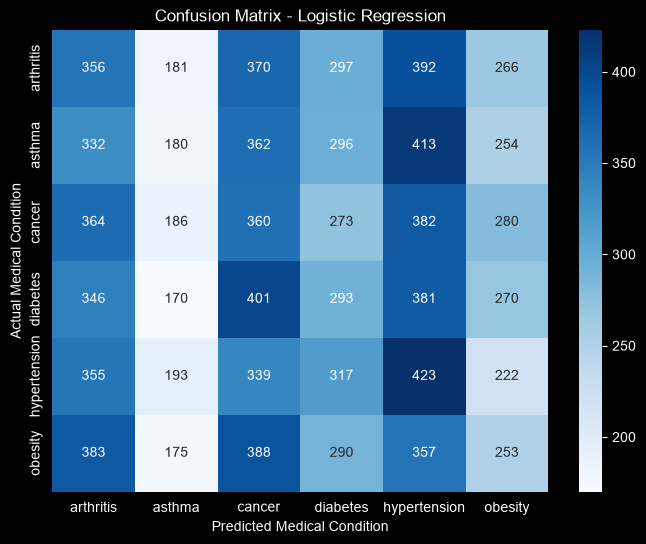

In [16]:
cm = confusion_matrix(y_test, predictions, labels=model.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_,
    cmap="Blues"
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Medical Condition")
plt.ylabel("Actual Medical Condition")
plt.show()

In [17]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy:  {test_accuracy:.4f}")

Training Accuracy: 0.1768
Testing Accuracy:  0.1680


## 10. Conclusion

Fill this in after running against your real `hospital.csv`:

- If test accuracy is only marginally above the baseline, the
  available features (`Age`, `Gender`, `Blood Type`, `Admission Type`,
  `Medication`, `Test Results`) don't carry a strong real relationship
  with `Medical Condition` in this dataset, and no amount of
  hyperparameter tuning on Logistic Regression will fix that —
  a different target (e.g. `Test Results`, `Admission Type`, or a
  regression on `Billing Amount` / length of stay) would be a better
  use of this pipeline.
- If accuracy is clearly above baseline, this pipeline is a solid
  foundation — next steps would be trying `class_weight="balanced"`,
  regularization tuning (`C` parameter), or comparing against a
  tree-based model.